In [1]:
# 기본 데이터 처리 도구
import pandas as pd          # 표(테이블) 형태의 데이터를 다루는 도구
import numpy as np           # 숫자 계산을 빠르게 해주는 도구
import matplotlib.pyplot as plt  # 그래프를 그려주는 도구
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'  # 한글 폰트 (없으면 네모 표시됨)
matplotlib.rcParams['axes.unicode_minus'] = False

# 딥러닝(AI 학습) 도구
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# 성능 평가 도구
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print(" 모든 도구를 성공적으로 불러왔습니다!")
print(f"   TensorFlow 버전: {tf.__version__}")


 모든 도구를 성공적으로 불러왔습니다!
   TensorFlow 버전: 2.21.0


## 2단계: 데이터 불러오기

>  **데이터 설명**  
> - **train.csv** : AI가 공부할 교재 (22,194개 뉴스)  
> - **validation.csv** : 공부 중간중간 확인하는 쪽지시험 (2,466개)  
> - **test.csv** : 최종 시험 (2,740개)  
> 
> 각 뉴스에는 **제목(title)**, **본문(document)**, **요약(summary)**, **카테고리(category)** 가 있습니다.


In [2]:
# CSV 파일 읽기
train_df = pd.read_csv('train.csv')
val_df   = pd.read_csv('validation.csv')
test_df  = pd.read_csv('test.csv')

print("=" * 50)
print(f" 훈련 데이터:   {len(train_df):,}개")
print(f" 검증 데이터:   {len(val_df):,}개")
print(f" 테스트 데이터: {len(test_df):,}개")
print("=" * 50)
print()
print(" 데이터 미리보기 (처음 3행):")
train_df[['title', 'summary', 'category']].head(3)


 훈련 데이터:   22,194개
 검증 데이터:   2,466개
 테스트 데이터: 2,740개

 데이터 미리보기 (처음 3행):


,title,summary,category
0,추경호 중기 수출지원 총력 무역금융 40조 확대,"올해 상반기 우리나라 무역수지는 역대 최악인 103억 달러 적자를 기록한 가운데, ...",economy
1,해산물·주류 무제한 인터컨티넨탈 뷔페 여름 한정 페스타 연다,인터엑스 1층 뷔페 레스토랑 브래서리는 오는 6일부터 8월31일까지 쿨 섬머 페스타...,economy
2,한국인 생활 변화시킨 의사 마지막까지 영향력 컸던 과학자 이호왕 고려대 명예교수 소천,이 이호왕 고려대 명예교수는 바이러스의 병원체와 진단법 백신까지 모두 개발한 한국을...,IT과학


 카테고리별 뉴스 수:
category
economy    17088
IT과학        5106
Name: count, dtype: int64



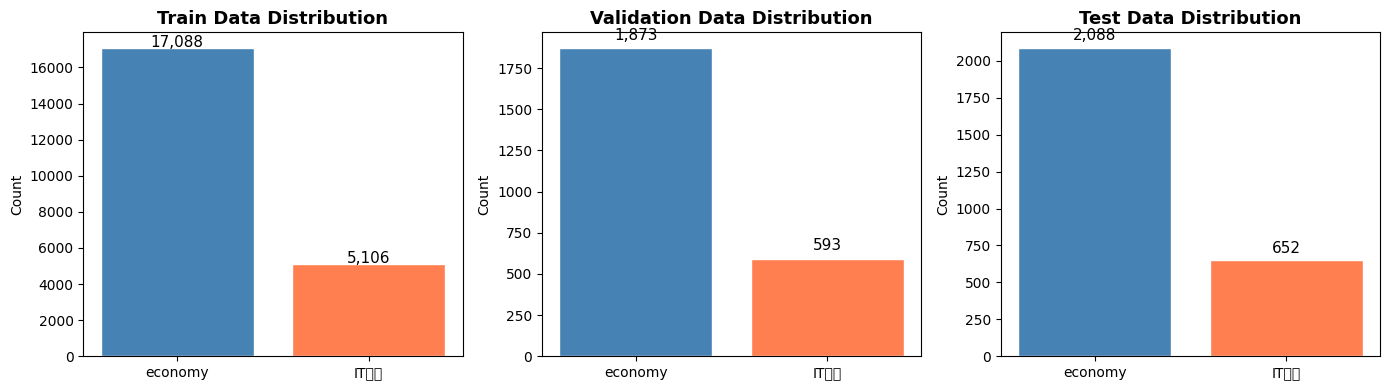

In [3]:
# 카테고리(정답) 분포 확인
print(" 카테고리별 뉴스 수:")
print(train_df['category'].value_counts())
print()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (df, name) in zip(axes, [(train_df,'Train'), (val_df,'Validation'), (test_df,'Test')]):
    counts = df['category'].value_counts()
    ax.bar(counts.index, counts.values, color=['steelblue', 'coral'], edgecolor='white')
    ax.set_title(f'{name} Data Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 3단계: 텍스트 전처리 - 문자를 숫자로 변환

>  **왜 숫자로 바꿔야 할까요?**  
> 컴퓨터(AI)는 글자를 직접 이해하지 못합니다. 오직 **숫자**만 처리할 수 있어요.  
> 예를 들어 "경제" → 342, "성장" → 1205 처럼 각 단어에 번호를 붙여주는 과정입니다.
>
> ### 처리 순서
> 1. **입력 텍스트 선택**: 제목(title) + 요약(summary)을 합쳐서 사용
> 2. **토큰화(Tokenization)**: 문장을 단어 단위로 쪼개고 번호 부여
> 3. **패딩(Padding)**: 문장 길이를 동일하게 맞춤 (짧은 문장엔 0을 채움)
> 4. **레이블 인코딩**: 카테고리도 숫자로 변환 (economy=0, IT과학=1)


In [4]:
# ── 입력 텍스트: 제목 + 요약 합치기 ──────────────────────────────────────
# 제목과 요약을 합치면 정보가 더 풍부해져서 분류 정확도가 올라갑니다
def combine_text(df):
    return (df['title'].fillna('') + ' ' + df['summary'].fillna('')).str.strip()

train_texts = combine_text(train_df)
val_texts   = combine_text(val_df)
test_texts  = combine_text(test_df)

# 예시 출력
print(" 입력 텍스트 예시 (제목 + 요약 합치기):")
print(train_texts.iloc[0][:150], "...")


 입력 텍스트 예시 (제목 + 요약 합치기):
추경호 중기 수출지원 총력 무역금융 40조 확대 올해 상반기 우리나라 무역수지는 역대 최악인 103억 달러 적자를 기록한 가운데, 정부가 하반기에 우리 경제의 버팀목인 수출 확대를 위해 총력을 기울이기로 결정한 가운데, 특히 수출 중소기업의 물류난 해소를 위해 무역금융 ...


In [5]:
# ── 토큰화: 단어 → 번호 사전 만들기 ─────────────────────────────────────
MAX_VOCAB  = 30000   # 사용할 단어 최대 개수 (자주 나오는 상위 3만 개)
MAX_LENGTH = 100     # 문장 최대 길이 (100 단어 기준)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
# oov_token: 사전에 없는 모르는 단어는 '<OOV>'로 처리
tokenizer.fit_on_texts(train_texts)  # 훈련 데이터로만 사전 구축!

word_index = tokenizer.word_index
print(f" 총 단어 사전 크기: {len(word_index):,}개")
print()
print(" 단어-번호 예시 (상위 10개):")
for word, idx in list(word_index.items())[1:11]:
    print(f"   '{word}' → {idx}")


 총 단어 사전 크기: 168,318개

 단어-번호 예시 (상위 10개):
   '등' → 2
   '수' → 3
   '있는' → 4
   '5일' → 5
   '밝혔다' → 6
   '4일' → 7
   '있다' → 8
   '것으로' → 9
   '및' → 10
   '위해' → 11


In [6]:
# ── 문장을 번호 배열로 변환 + 패딩 ──────────────────────────────────────
def texts_to_padded(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    # pad_sequences: 모든 문장 길이를 MAX_LENGTH로 맞춤
    # padding='post'  → 문장 뒤에 0 추가
    # truncating='post' → 긴 문장은 뒤에서 자름
    return pad_sequences(sequences, maxlen=MAX_LENGTH,
                         padding='post', truncating='post')

X_train = texts_to_padded(train_texts)
X_val   = texts_to_padded(val_texts)
X_test  = texts_to_padded(test_texts)

# 예시: 첫 번째 뉴스가 어떻게 변환됐는지 확인
print(" 변환 전 텍스트:")
print(" ", train_texts.iloc[0][:80], "...")
print()
print(" 변환 후 숫자 배열 (앞 20개):")
print(" ", X_train[0][:20], "...")
print(f"\n훈련 데이터 최종 형태: {X_train.shape}  → (뉴스 수, 단어 수)")


 변환 전 텍스트:
  추경호 중기 수출지원 총력 무역금융 40조 확대 올해 상반기 우리나라 무역수지는 역대 최악인 103억 달러 적자를 기록한 가운데, 정부가 하반기 ...

 변환 후 숫자 배열 (앞 20개):
  [ 132 4851    1 6838 3850 3750  127   19   60  421 3545  152    1 2013
  257 1130  461   17  265 2080] ...

훈련 데이터 최종 형태: (22194, 100)  → (뉴스 수, 단어 수)


In [7]:
# ── 정답(카테고리)도 숫자로 변환 ─────────────────────────────────────────
le = LabelEncoder()
y_train = le.fit_transform(train_df['category'])  # economy=0, IT과학=1
y_val   = le.transform(val_df['category'])
y_test  = le.transform(test_df['category'])

print(" 카테고리 → 숫자 매핑:")
for i, cls in enumerate(le.classes_):
    print(f"   {cls}  →  {i}")
print()
print(f"훈련 정답 예시: {y_train[:10]}")


 카테고리 → 숫자 매핑:
   IT과학  →  0
   economy  →  1

훈련 정답 예시: [1 1 0 1 1 1 0 1 1 1]


## 4단계: LSTM 모델 만들기

> ###  LSTM이란?
> **Long Short-Term Memory** (장단기 기억 신경망)의 약자입니다.
>
> 일반적인 AI는 앞뒤 문맥을 기억하지 못하고 단어를 하나씩 독립적으로 봅니다.  
> 하지만 LSTM은 마치 사람처럼 **앞에 나온 단어를 기억하면서** 다음 단어를 해석합니다.
>
> 예: "금리 인상으로 주식 시장이..." → LSTM은 "금리, 인상, 주식, 시장"을 연결해서  
> "이건 경제 뉴스겠구나!" 하고 판단합니다.
>
> ###  모델 구조
> ```
> [입력] 100개 단어 번호
>    ↓
> Embedding층  → 단어 번호를 의미 있는 벡터(숫자 묶음)로 변환
>    ↓
> LSTM층       → 문맥을 기억하며 중요한 패턴 학습
>    ↓
> Dropout층    → 과적합 방지 (암기 방지, 이해 유도)
>    ↓
> Dense층      → 최종 분류 결정
>    ↓
> [출력] economy / IT과학 확률
> ```


In [8]:
# ── 모델 구성 ──────────────────────────────────────────────────────────
EMBED_DIM  = 128   # 각 단어를 128차원 벡터로 표현
LSTM_UNITS = 64    # LSTM이 기억할 수 있는 정보의 크기

model = Sequential([
    # 1) Embedding: 단어 번호 → 의미 벡터
    #    예) 342 → [0.2, -0.5, 0.8, ...]  (128개 숫자)
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM,
              input_length=MAX_LENGTH),

    # 2) LSTM: 앞뒤 문맥을 기억하며 핵심 패턴 추출
    LSTM(LSTM_UNITS, return_sequences=False),

    # 3) Dropout: 훈련 중 30%의 뉴런을 무작위로 끔
    #    → 특정 패턴에만 의존하는 '암기'를 방지하고 '이해'를 유도
    Dropout(0.3),

    # 4) Dense(출력층): 최종 분류 (이진분류 → sigmoid 사용)
    Dense(1, activation='sigmoid')
    # sigmoid: 0~1 사이 확률값 반환
    # 0에 가까우면 economy, 1에 가까우면 IT과학
])

# 모델 컴파일: 학습 방식 설정
model.compile(
    optimizer='adam',          # Adam: 가장 많이 쓰이는 최적화 알고리즘
    loss='binary_crossentropy',# 이진분류에 적합한 손실함수
    metrics=['accuracy']       # 정확도를 기준으로 평가
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5단계: 모델 훈련 (학습)

>  **에포크(Epoch)란?**  
> 훈련 데이터 전체를 한 번 다 보는 것을 1 에포크라고 합니다.  
> 10 에포크 = 같은 교재를 10번 반복해서 공부하는 것!
>
>  **Early Stopping이란?**  
> 검증 성능이 더 이상 오르지 않으면 자동으로 훈련을 멈춥니다.  
> 과도한 암기(과적합)를 방지하고, 불필요한 시간 낭비를 줄입니다.


In [9]:
# ── 훈련 시작 ──────────────────────────────────────────────────────────
# EarlyStopping: 검증 손실이 3번 연속 나빠지면 훈련 중단
early_stop = EarlyStopping(
    monitor='val_loss',    # 검증 손실을 기준으로
    patience=3,            # 3번 연속 나빠지면 중단
    restore_best_weights=True  # 가장 좋았던 시점의 가중치 복원
)

print(" 모델 훈련 시작!")
print("   (시간이 조금 걸릴 수 있습니다...)")
print()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,          # 최대 10번 반복
    batch_size=64,      # 한 번에 64개씩 학습
    callbacks=[early_stop],
    verbose=1
)

print()
print(" 훈련 완료!")


 모델 훈련 시작!
   (시간이 조금 걸릴 수 있습니다...)

Epoch 1/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 29s 76ms/step - accuracy: 0.7698 - loss: 0.5457 - val_accuracy: 0.7595 - val_loss: 0.5532
Epoch 2/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.7703 - loss: 0.5412 - val_accuracy: 0.7595 - val_loss: 0.5515
Epoch 3/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.7707 - loss: 0.5395 - val_accuracy: 0.7591 - val_loss: 0.5522
Epoch 4/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.7714 - loss: 0.5375 - val_accuracy: 0.7591 - val_loss: 0.5516
Epoch 5/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.7702 - loss: 0.5186 - val_accuracy: 0.7591 - val_loss: 0.5221
Epoch 6/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.8194 - loss: 0.4069 - val_accuracy: 0.8386 - val_loss: 0.3810
Epoch 7/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.8906 - loss: 0.2843 - val_accuracy: 0.8609 - val_loss: 0.3296
Epoch 8/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step

## 6단계: 학습 과정 시각화

> 학습이 잘 됐다면 아래 그래프에서:
> - **정확도(Accuracy)**: 에포크가 늘수록 점점 올라가야 합니다 
> - **손실(Loss)**: 에포크가 늘수록 점점 내려가야 합니다 


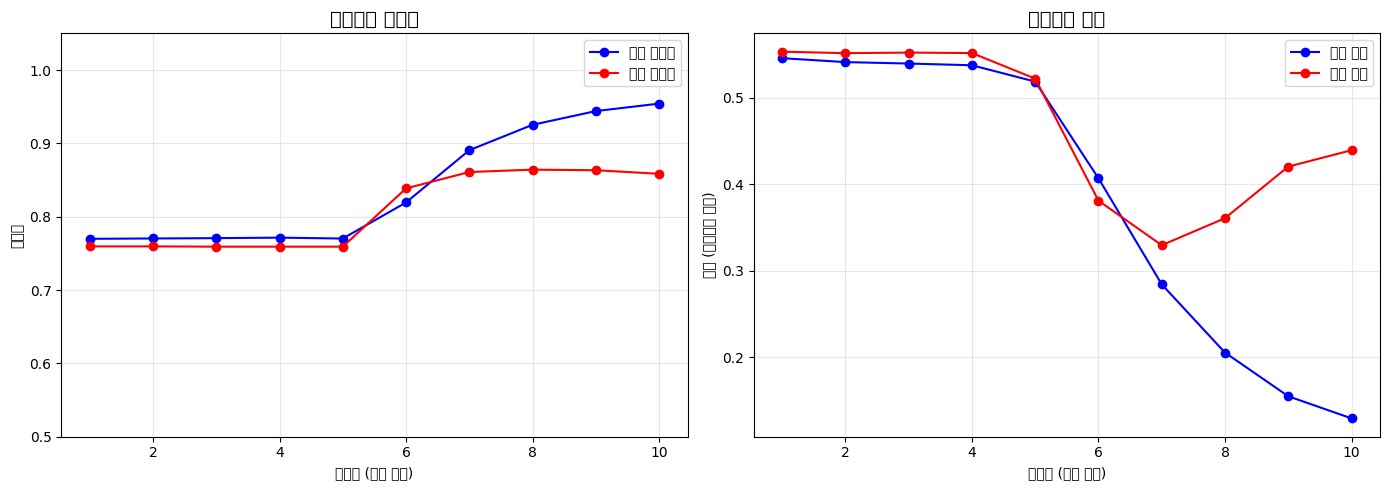

최고 검증 정확도: 0.8642 (86.42%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# 정확도 그래프
axes[0].plot(epochs_ran, history.history['accuracy'],     'b-o', label='훈련 정확도')
axes[0].plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='검증 정확도')
axes[0].set_title('에포크별 정확도', fontsize=14, fontweight='bold')
axes[0].set_xlabel('에포크 (반복 횟수)')
axes[0].set_ylabel('정확도')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.5, 1.05])

# 손실 그래프
axes[1].plot(epochs_ran, history.history['loss'],     'b-o', label='훈련 손실')
axes[1].plot(epochs_ran, history.history['val_loss'], 'r-o', label='검증 손실')
axes[1].set_title('에포크별 손실', fontsize=14, fontweight='bold')
axes[1].set_xlabel('에포크 (반복 횟수)')
axes[1].set_ylabel('손실 (낮을수록 좋음)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f"최고 검증 정확도: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


## 7단계: 테스트 데이터로 최종 성능 평가

> 이제 모델이 한 번도 본 적 없는 **테스트 데이터**로 진짜 실력을 측정합니다.
>
> ###  평가 지표 설명
> | 지표 | 의미 |
> |------|------|
> | **Accuracy** | 전체 중 맞춘 비율 |
> | **Precision** | "IT과학이다"라고 예측했을 때 실제로 맞은 비율 |
> | **Recall** | 실제 IT과학 뉴스 중에 제대로 잡아낸 비율 |
> | **F1-score** | Precision과 Recall의 균형 지표 (클수록 좋음) |


In [11]:
# 테스트 데이터 예측
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 전체 정확도
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"{'='*50}")
print(f" 테스트 정확도: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f" 테스트 손실:   {test_loss:.4f}")
print(f"{'='*50}")
print()

# 상세 분류 리포트
print(" 상세 분류 리포트:")
print(classification_report(y_test, y_pred,
                             target_names=le.classes_,
                             digits=4))


 테스트 정확도: 0.8770 (87.70%)
 테스트 손실:   0.3131

 상세 분류 리포트:
              precision    recall  f1-score   support

        IT과학     0.7647    0.6979    0.7298       652
     economy     0.9082    0.9330    0.9204      2088

    accuracy                         0.8770      2740
   macro avg     0.8364    0.8154    0.8251      2740
weighted avg     0.8740    0.8770    0.8750      2740



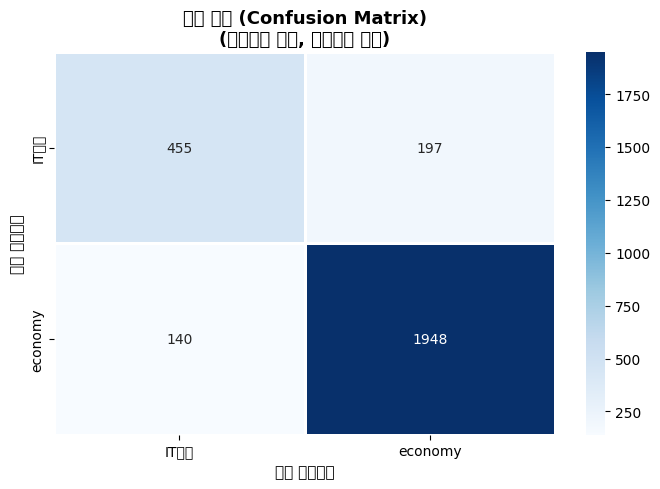

 해석 방법:
   - 실제 economy → economy 예측: 455개 
   - 실제 economy → IT과학 예측:  197개 
   - 실제 IT과학  → economy 예측: 140개 
   - 실제 IT과학  → IT과학 예측:  1,948개 


In [12]:
# ── 혼동 행렬 (Confusion Matrix) ─────────────────────────────────────────
# 모델이 어디서 헷갈렸는지 한눈에 볼 수 있습니다
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1, linecolor='white')
plt.title('혼동 행렬 (Confusion Matrix)\n(대각선이 정답, 나머지는 오답)', fontsize=13, fontweight='bold')
plt.ylabel('실제 카테고리', fontsize=11)
plt.xlabel('예측 카테고리', fontsize=11)
plt.tight_layout()
plt.show()

print(" 해석 방법:")
print(f"   - 실제 economy → economy 예측: {cm[0][0]:,}개 ")
print(f"   - 실제 economy → IT과학 예측:  {cm[0][1]:,}개 ")
print(f"   - 실제 IT과학  → economy 예측: {cm[1][0]:,}개 ")
print(f"   - 실제 IT과학  → IT과학 예측:  {cm[1][1]:,}개 ")


## 8단계: 새로운 뉴스 직접 예측해보기

> 이제 여러분이 직접 뉴스 문장을 입력해서 모델이 어떻게 분류하는지 확인해봅시다! 🎉


In [13]:
def predict_news(text):
    """
    뉴스 텍스트를 입력받아 카테고리와 확률을 출력하는 함수
    """
    # 1. 텍스트 → 숫자 배열 변환
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

    # 2. 예측
    prob = model.predict(padded, verbose=0)[0][0]

    # 3. 결과 해석
    category = le.classes_[1] if prob > 0.5 else le.classes_[0]
    confidence = prob if prob > 0.5 else 1 - prob

    print(f" 입력 텍스트: {text[:80]}...")
    print(f" 예측 카테고리: [{category}]")
    print(f" 확신도: {confidence*100:.1f}%")
    print("-" * 60)

# ── 예시 테스트 ──────────────────────────────────────────────────────────
print("=" * 60)
print(" 직접 예측 테스트")
print("=" * 60)
print()

# 경제 뉴스 예시
predict_news("한국은행 기준금리 인상 결정 물가 상승 압력 대응 금융위원회")

# IT 뉴스 예시
predict_news("삼성전자 갤럭시 신제품 출시 AI 기능 탑재 스마트폰 반도체")

# 직접 입력 예시
predict_news("코스피 하락세 외국인 매도 주식 시장 불안 환율 상승")


 직접 예측 테스트

 입력 텍스트: 한국은행 기준금리 인상 결정 물가 상승 압력 대응 금융위원회...
 예측 카테고리: [economy]
 확신도: 97.8%
------------------------------------------------------------
 입력 텍스트: 삼성전자 갤럭시 신제품 출시 AI 기능 탑재 스마트폰 반도체...
 예측 카테고리: [economy]
 확신도: 58.3%
------------------------------------------------------------
 입력 텍스트: 코스피 하락세 외국인 매도 주식 시장 불안 환율 상승...
 예측 카테고리: [economy]
 확신도: 90.1%
------------------------------------------------------------


In [14]:
# ── 여러분이 직접 텍스트를 넣어보세요! ──────────────────────────────────
my_news = "원하는 뉴스 문장을 여기에 입력하세요"

predict_news(my_news)


 입력 텍스트: 원하는 뉴스 문장을 여기에 입력하세요...
 예측 카테고리: [economy]
 확신도: 77.8%
------------------------------------------------------------


## 전체 정리

| 단계 | 내용 |
|------|------|
| **1단계** | 필요한 라이브러리(도구) 불러오기 |
| **2단계** | 뉴스 데이터 로드 및 분포 확인 |
| **3단계** | 텍스트 → 숫자 변환 (토큰화 + 패딩) |
| **4단계** | LSTM 모델 구성 |
| **5단계** | 모델 훈련 (Early Stopping 적용) |
| **6단계** | 학습 곡선 시각화 |
| **7단계** | 테스트 데이터 성능 평가 |
| **8단계** | 새로운 뉴스 직접 예측 |

---

### 핵심 개념 복습

**LSTM (Long Short-Term Memory)**  
단어의 순서와 문맥을 기억하는 순환 신경망.  
"금리"와 "인상"이 같은 문장에 있으면 경제 뉴스라는 걸 파악합니다.

**Embedding (임베딩)**  
단어를 단순 번호가 아닌 의미를 담은 숫자 벡터로 표현.  
"주식"과 "채권"은 비슷한 위치에, "주식"과 "스마트폰"은 멀리 위치하도록 학습됩니다.

**Dropout (드롭아웃)**  
훈련 중 일부 뉴런을 무작위로 꺼서 특정 패턴 암기를 방지합니다.

---
>  더 나아가려면: 양방향 LSTM (BiLSTM), 어텐션 메커니즘, BERT 등을 공부해보세요!
